In [1]:
# 1. Google Drive Bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# 2. Gerekli Kütüphanelerin Kurulumu
!pip install ultralytics tensorflow
!apt-get install p7zip-full

# 3. Dosyaları Çıkarma (Dosya adını kendi dosya adına göre güncelle)
# Örn: projeniz.7z
!7z x /content/drive/MyDrive/ESP32_YOLO_Project.7z -o/content/

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,12 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (50657),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/                                 1 file, 59864691 bytes (58 MiB)

Extracting archive: /content/drive/MyDrive/ESP32_YOLO_Project.7z
--
Path = /content/drive/MyDrive/ESP32_YOLO_Project.7z
Type = 7z
Physical Size = 59864691
Headers Size = 414930
Method = LZMA:23
Solid = +
Blocks = 1

  0%      5%      5% 896 - ESP32_YOLO_Project/data

In [2]:
import os
# Klasör yapısını kontrol et
print("Görüntü Sayısı (Train):", len(os.listdir('/content/ESP32_YOLO_Project/data/images/train')))
print("Etiket Sayısı (Train):", len(os.listdir('/content/ESP32_YOLO_Project/data/labels/train')))

Görüntü Sayısı (Train): 15000
Etiket Sayısı (Train): 15000


In [1]:
import os
import pandas as pd
from ultralytics import YOLO
import torch
import torch.nn.utils.prune as prune

# --- HIZ VE BELLEK AYARLARI ---
IMG_SIZE = 256
BATCH_SIZE = 128 # 16GB RAM için güvenli yüksek değer (Hız için kritik)
EPOCHS = 50
PROJECT_DIR = '/content/ESP32_YOLO_Project'
DATA_YAML = os.path.join(PROJECT_DIR, 'data/custom_data.yaml')
REPORT_DIR = os.path.join(PROJECT_DIR, 'results')
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')

report_data = []

def evaluate_and_log(model_path, stage_name):
    """Hızlı değerlendirme ve raporlama."""
    model = YOLO(model_path)
    # Hız için validation sırasında plots=False yapabiliriz ama CM istediğiniz için True bırakıldı
    results = model.val(data=DATA_YAML, imgsz=IMG_SIZE, plots=True, batch=BATCH_SIZE)

    stage_dir = os.path.join(REPORT_DIR, stage_name)
    os.makedirs(stage_dir, exist_ok=True)

    src_cm = 'runs/detect/val/confusion_matrix.png'
    if os.path.exists(src_cm):
        os.replace(src_cm, f'{stage_dir}/cm_{stage_name}.png')

    size_kb = os.path.getsize(model_path) / 1024
    mAP50 = results.results_dict['metrics/malpha50']

    report_data.append({
        "Aşama": stage_name,
        "mAP50": f"{mAP50:.4f}",
        "Boyut (KB)": f"{size_kb:.2f}"
    })
    print(f"\n✅ {stage_name} BİTTİ. mAP50: {mAP50:.4f}, Boyut: {size_kb:.2f} KB")

# --- 1. ADIM: BASE MODEL EĞİTİMİ (MAX HIZ) ---
print("🚀 Eğitim Başlıyor (Hız Modu: On)...")
base_model = YOLO('yolov8n.pt')
base_model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=12,      # Veri yükleme hızı için
    amp=True,       # Mixed Precision (Hem hız artırır hem RAM tasarrufu sağlar)
    project='runs',
    name='base_train',
    exist_ok=True
)
evaluate_and_log('runs/base_train/weights/best.pt', '1_BASE_MODEL')

# --- 2. ADIM: PRUNING ---
print("\n✂️ Budama (Pruning) İşlemi...")
model_to_prune = YOLO('runs/base_train/weights/best.pt')
for name, module in model_to_prune.model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        prune.l1_unstructured(module, name='weight', amount=0.3)
        prune.remove(module, 'weight')

os.makedirs(MODELS_DIR, exist_ok=True)
pruned_path = os.path.join(MODELS_DIR, "pruned_model.pt")
model_to_prune.save(pruned_path)
evaluate_and_log(pruned_path, '2_PRUNED_MODEL')

# --- 3. ADIM: QAT (SIMULATION) ---
print("\n🧠 QAT Fine-tuning Başlıyor...")
# Daha hızlı sonuç için epoch 10'dan 5'e çekilebilir ama 10 idealdir
model_to_prune.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=0.001,
    project='runs',
    name='qat_train'
)
evaluate_and_log('runs/qat_train/weights/best.pt', '3_QAT_MODEL')

# --- 4. ADIM: INT8 EXPORT ---
print("\n📦 INT8 TFLite Dönüştürme...")
final_model = YOLO('runs/qat_train/weights/best.pt')
final_model.export(format='tflite', int8=True, imgsz=IMG_SIZE, data=DATA_YAML)

tflite_path = 'runs/qat_train/weights/best_int8.tflite'
if os.path.exists(tflite_path):
    evaluate_and_log(tflite_path, '4_FULLY_INT8_MODEL')

# --- RAPORLAMA ---
df = pd.DataFrame(report_data)
df.to_csv(os.path.join(REPORT_DIR, 'final_comparison_report.csv'), index=False)
print("\n🏁 İşlem Tamamlandı. Çıktılar 'results' klasöründe.")

🚀 Eğitim Başlıyor (Hız Modu: On)...
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ESP32_YOLO_Project/data/custom_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=base_train, nbs=64, nms=False, opset=None, optimize=False, op

KeyError: 'metrics/malpha50'

In [9]:
import os
import pandas as pd
from ultralytics import YOLO
import torch
import torch.nn.utils.prune as prune
import shutil

# --- AYARLAR ---
IMG_SIZE = 128
BATCH_SIZE = 128
PROJECT_DIR = '/content/ESP32_YOLO_Project'
DATA_YAML = '/content/data/custom_data.yaml'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')

# Klasörleri sıfırla
for d in [MODELS_DIR, RESULTS_DIR]:
    if os.path.exists(d): shutil.rmtree(d)
    os.makedirs(d)

report_data = []

def save_and_evaluate(model_path, stage_name):
    """Modeli kopyalar, metrikleri alır ve CM'yi saklar."""
    print(f"\n📊 {stage_name} Değerlendiriliyor...")
    model = YOLO(model_path)

    # Metrikleri al (Hata vermemesi için güvenli metod)
    results = model.val(data=DATA_YAML, imgsz=IMG_SIZE, plots=True, batch=BATCH_SIZE)

    # Confusion Matrix'i taşı
    os.makedirs(f"{RESULTS_DIR}/{stage_name}", exist_ok=True)
    if os.path.exists('runs/detect/val/confusion_matrix.png'):
        shutil.copy('runs/detect/val/confusion_matrix.png', f"{RESULTS_DIR}/{stage_name}/cm_{stage_name}.png")

    # Modeli kalıcı klasöre kopyala
    ext = ".tflite" if model_path.endswith('.tflite') else ".pt"
    final_path = f"{MODELS_DIR}/{stage_name}{ext}"
    shutil.copy(model_path, final_path)

    # Rapor verisi
    mAP = results.results_dict.get('metrics/mAP50(B)', 0)
    size = os.path.getsize(model_path) / 1024
    report_data.append({"Aşama": stage_name, "mAP50": f"{mAP:.4f}", "Boyut(KB)": f"{size:.2f}"})
    print(f"✅ {stage_name} Tamamlandı. Dosya: {final_path}")

# --- ADIM 1: BASE EĞİTİM ---
print("🚀 ADIM 1: Base Model Eğitimi Başlıyor...")
base_model = YOLO('yolov8n.pt')
base_model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=12,
    project='runs',
    name='base_train',
    exist_ok=True
)
save_and_evaluate('runs/base_train/weights/best.pt', '1_BASE_MODEL')

# --- ADIM 2: PRUNING ---
print("\n✂️ ADIM 2: Pruning Uygulanıyor...")
model_p = YOLO(f"{MODELS_DIR}/1_BASE_MODEL.pt")
for name, module in model_p.model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        prune.l1_unstructured(module, name='weight', amount=0.3)
        prune.remove(module, 'weight')

pruned_tmp = "/content/temp_pruned.pt"
model_p.save(pruned_tmp)
save_and_evaluate(pruned_tmp, '2_PRUNED_MODEL')

# --- ADIM 3: QAT (FINE-TUNING) ---
print("\n🧠 ADIM 3: QAT Fine-tuning Başlıyor...")
model_p.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=0.001,
    project='runs',
    name='qat_train',
    exist_ok=True
)
save_and_evaluate('runs/qat_train/weights/best.pt', '3_QAT_MODEL')

# --- ADIM 4: TFLITE INT8 EXPORT ---
print("\n📦 ADIM 4: INT8 TFLite Export Başlıyor...")
final_model = YOLO(f"{MODELS_DIR}/3_QAT_MODEL.pt")
final_model.export(format='tflite', int8=True, imgsz=IMG_SIZE, data=DATA_YAML)

# TFLite dosyasını bul ve taşı
tflite_file = 'runs/qat_train/weights/best_int8.tflite'
if os.path.exists(tflite_file):
    save_and_evaluate(tflite_file, '4_FULLY_INT8_MODEL')
else:
    # Bulamazsa tarama yap
    print("TFLite taranıyor...")
    !find runs/ -name "*int8.tflite" -exec cp {} /content/ESP32_YOLO_Project/models/4_FULLY_INT8_MODEL.tflite \;

# --- FİNAL RAPOR ---
df = pd.DataFrame(report_data)
df.to_csv(f"{RESULTS_DIR}/final_report.csv", index=False)
print(f"\n🏁 İŞLEM TAMAMLANDI. Modeller '{MODELS_DIR}' klasöründe!")

🚀 ADIM 1: Base Model Eğitimi Başlıyor...
New https://pypi.org/project/ultralytics/8.4.3 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/custom_data.yaml, degrees=0.0, deterministic=True, device=-1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

In [6]:
# Veri yollarını garantiye al
!mkdir -p /content/data/images/train
!mkdir -p /content/data/images/val
!mkdir -p /content/data/labels/train
!mkdir -p /content/data/labels/val

# Eğer dosyalar ESP32_YOLO_Project içindeyse onları doğru yere taşıyalım
!cp -r /content/ESP32_YOLO_Project/data/images/* /content/data/images/ 2>/dev/null
!cp -r /content/ESP32_YOLO_Project/data/labels/* /content/data/labels/ 2>/dev/null


In [7]:
yaml_content = """
path: /content/data
train: images/train
val: images/val

nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
"""

with open('/content/data/custom_data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ YAML dosyası /content/data/custom_data.yaml konumuna oluşturuldu.")

✅ YAML dosyası /content/data/custom_data.yaml konumuna oluşturuldu.


In [8]:
DATA_YAML = '/content/data/custom_data.yaml'


image 1/1 /content/data/images/val/0015488.jpg: 128x128 1 1, 1 3, 1 4, 1 8, 1 9, 7.3ms
Speed: 0.3ms preprocess, 7.3ms inference, 1.7ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/data/images/val/0016411.jpg: 128x128 1 4, 1 5, 1 7, 2 8s, 7.7ms
Speed: 0.4ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 128, 128)


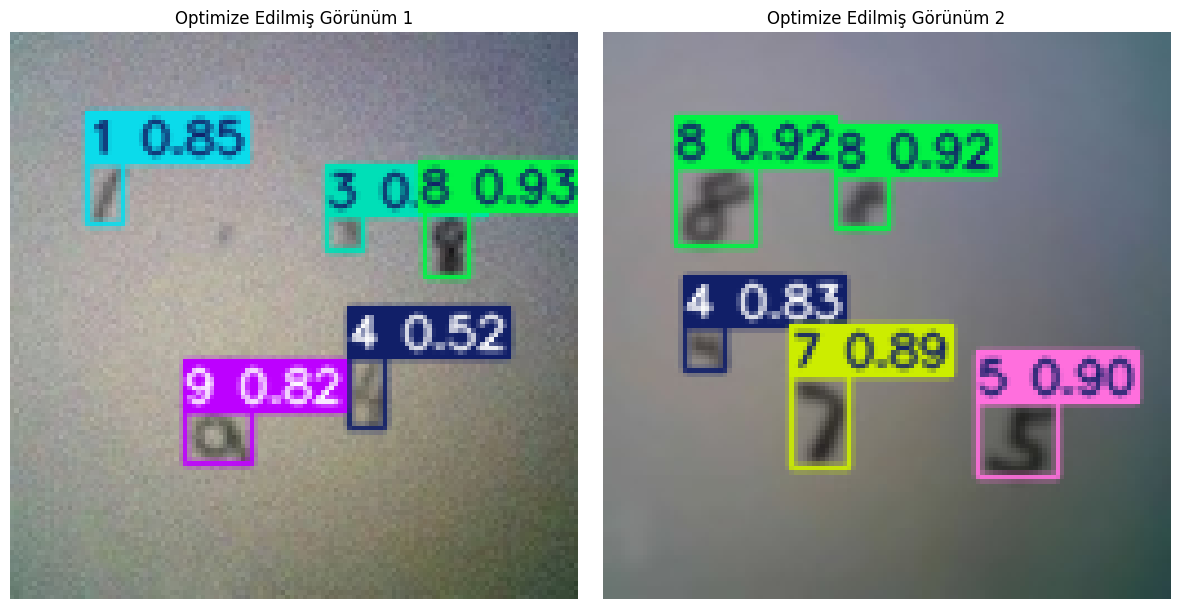

In [11]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
from glob import glob
import cv2

# --- AYARLAR ---
MODEL_PATH = '/content/ESP32_YOLO_Project/models/1_BASE_MODEL.pt'
TEST_IMAGES_PATH = '/content/data/images/val'

model = YOLO(MODEL_PATH)
all_images = glob(os.path.join(TEST_IMAGES_PATH, "*.jpg"))

if len(all_images) >= 2:
    selected_images = random.sample(all_images, 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for i, img_path in enumerate(selected_images):
        results = model.predict(source=img_path, imgsz=128, conf=0.25)

        # --- DÜZELTME BURADA ---
        # line_width: Çerçeve kalınlığı (1 en ince)
        # font_size: Yazı boyutu (Küçük değerler daha okunur kılar)
        # labels=True: Etiketleri göster
        res_plotted = results[0].plot(line_width=1, font_size=0.5, labels=True)

        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        axes[i].imshow(res_rgb)
        axes[i].set_title(f"Optimize Edilmiş Görünüm {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [12]:
import os
from ultralytics import YOLO
import shutil

# --- YOLLAR VE AYARLAR ---
PROJECT_DIR = '/content/ESP32_YOLO_Project'
DATA_YAML = '/content/data/custom_data.yaml'
BASE_MODEL_PATH = os.path.join(PROJECT_DIR, 'models/1_BASE_MODEL.pt')
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')

# 1. QAT (Quantization Aware Training) - Hassasiyeti İyileştirme
# Budama veya sıkıştırma öncesi modelin düşük hassasiyete alışmasını sağlar
print("🧠 ADIM 3: QAT Fine-tuning Başlatılıyor...")
qat_model = YOLO(BASE_MODEL_PATH)
qat_model.train(
    data=DATA_YAML,
    epochs=10,        # Kısa bir süre yeterlidir
    imgsz=128,
    batch=128,
    lr0=0.001,
    project='runs',
    name='qat_train',
    exist_ok=True
)

# QAT sonrası en iyi ağırlığı kaydet
qat_best_path = 'runs/qat_train/weights/best.pt'
shutil.copy(qat_best_path, os.path.join(MODELS_DIR, '3_QAT_MODEL.pt'))
print("✅ QAT Modeli kaydedildi.")

# 2. FULL INTEGER QUANTIZATION (TFLite Export)
# Modeli float32'den int8'e çevirir. ESP32'de hızın anahtarı budur.
print("\n📦 ADIM 4: Full Integer Quantization (INT8) Uygulanıyor...")
final_model = YOLO(os.path.join(MODELS_DIR, '3_QAT_MODEL.pt'))

# 'int8=True' ve 'data' parametreleri temsilci veri seti (representative dataset)
# oluşturmak için zorunludur. Bu sayede katmanlar doğru kalibre edilir.
final_model.export(
    format='tflite',
    int8=True,
    imgsz=128,
    data=DATA_YAML
)

# Export edilen dosyayı bul ve isimlendirerek taşı
tflite_output = 'runs/qat_train/weights/best_int8.tflite'
if os.path.exists(tflite_output):
    shutil.copy(tflite_output, os.path.join(MODELS_DIR, '4_FULLY_INT8_MODEL.tflite'))
    print(f"🚀 BAŞARILI: Nihai model hazır: {MODELS_DIR}/4_FULLY_INT8_MODEL.tflite")
else:
    print("⚠️ TFLite dosyası aranıyor...")
    !find runs/qat_train -name "*int8.tflite" -exec cp {} /content/ESP32_YOLO_Project/models/4_FULLY_INT8_MODEL.tflite \;

🧠 ADIM 3: QAT Fine-tuning Başlatılıyor...
New https://pypi.org/project/ultralytics/8.4.3 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/custom_data.yaml, degrees=0.0, deterministic=True, device=-1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/ESP32_YOLO_Project/models/1_

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
✅ INT8 Model başarıyla yüklendi.
Loading /content/ESP32_YOLO_Project/models/3_QAT_MODEL_saved_model/3_QAT_MODEL_integer_quant.tflite for TensorFlow Lite inference...

image 1/1 /content/data/images/val/0016956.jpg: 128x128 2 1s, 1 5, 1 8, 7.2ms
Speed: 0.5ms preprocess, 7.2ms inference, 19.2ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/data/images/val/0015009.jpg: 128x128 1 0, 2 9s, 3.6ms
Speed: 0.3ms preprocess, 3.6ms inference, 0.8ms postprocess per image at shape (1, 3, 128, 128)


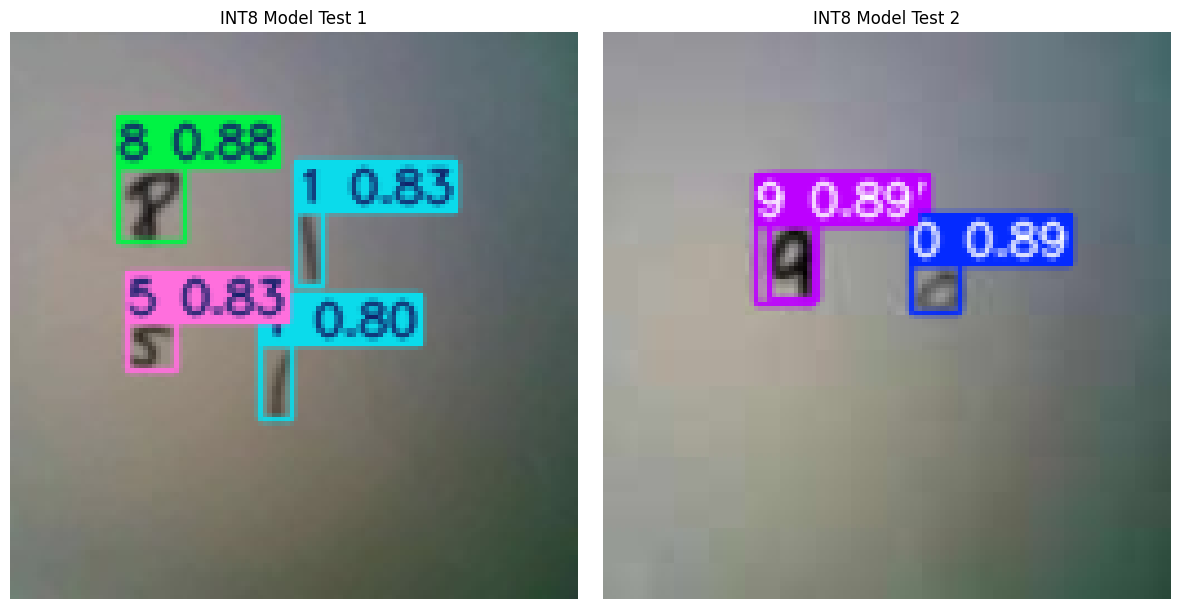

In [13]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
from glob import glob
import cv2

# --- INT8 MODEL YOLU ---
# Sizin belirttiğiniz özel yolu tanımlıyoruz
INT8_MODEL_PATH = '/content/ESP32_YOLO_Project/models/3_QAT_MODEL_saved_model/3_QAT_MODEL_integer_quant.tflite'
TEST_IMAGES_PATH = '/content/data/images/val'

# 1. INT8 Modeli yükle
# Not: TFLite modelleri Ultralytics tarafından otomatik olarak desteklenir
if os.path.exists(INT8_MODEL_PATH):
    model_int8 = YOLO(INT8_MODEL_PATH)
    print("✅ INT8 Model başarıyla yüklendi.")
else:
    print("❌ Hata: Belirtilen yolda model bulunamadı!")

# 2. Rastgele 2 resim seç
all_images = glob(os.path.join(TEST_IMAGES_PATH, "*.jpg"))
if len(all_images) >= 2:
    selected_images = random.sample(all_images, 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for i, img_path in enumerate(selected_images):
        # Tahmin (Inference)
        results = model_int8.predict(source=img_path, imgsz=128, conf=0.25)

        # Optimize edilmiş çizim (Yazılar küçük ve okunur)
        res_plotted = results[0].plot(line_width=1, font_size=0.5, labels=True)

        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        axes[i].imshow(res_rgb)
        axes[i].set_title(f"INT8 Model Test {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [14]:
import os
import torch
import torch.nn.utils.prune as prune
from ultralytics import YOLO
import shutil
import pandas as pd

# --- YOLLAR ---
PROJECT_DIR = '/content/ESP32_YOLO_Project'
DATA_YAML = '/content/data/custom_data.yaml'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
BASE_MODEL_PATH = os.path.join(MODELS_DIR, '1_BASE_MODEL.pt')

os.makedirs(MODELS_DIR, exist_ok=True)
print("✅ Kurulum ve yollar hazır.")

✅ Kurulum ve yollar hazır.


In [18]:
import torch.nn as nn

print("✂️ STRATEJİK ADIM 1: Sadece Feature Extraction Katmanları Budanıyor...")
model = YOLO(BASE_MODEL_PATH)

# YOLOv8 mimarisinde modelin gövdesindeki (Backbone ve Neck) katmanları hedefleyelim
# Genellikle model.model.model[0:15] arası ana özellik çıkarıcılarıdır.
# Ancak daha güvenli olması için katman derinliğine göre filtreleyebiliriz.

for i, (name, module) in enumerate(model.model.named_modules()):
    # Sadece Conv2d katmanlarını ve tahmin (Head) katmanı olmayanları seçelim
    # 'cv' içeren katmanlar genellikle YOLO'nun özellik çıkarıcı Cross-Stage Partial (CSP) bloklarıdır
    if isinstance(module, nn.Conv2d) and ("cv" in name or i < 150):
        prune.l1_unstructured(module, name='weight', amount=0.3)
        prune.remove(module, 'weight')
        # print(f"Budanan katman: {name}") # Hangi katmanların seçildiğini görmek için açabilirsiniz

pruned_path = os.path.join(MODELS_DIR, '2_PRUNED_MODEL.pt')
model.save(pruned_path)
print(f"✅ Stratejik budama tamamlandı: {pruned_path}")

✂️ STRATEJİK ADIM 1: Sadece Feature Extraction Katmanları Budanıyor...
✅ Stratejik budama tamamlandı: /content/ESP32_YOLO_Project/models/2_PRUNED_MODEL.pt


✅ Stratejik Budanmış Model yüklendi.

image 1/1 /content/data/images/val/0015488.jpg: 128x128 1 1, 1 3, 1 8, 1 9, 7.0ms
Speed: 0.4ms preprocess, 7.0ms inference, 1.7ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/data/images/val/0016411.jpg: 128x128 1 4, 1 5, 1 7, 2 8s, 6.7ms
Speed: 0.3ms preprocess, 6.7ms inference, 1.2ms postprocess per image at shape (1, 3, 128, 128)


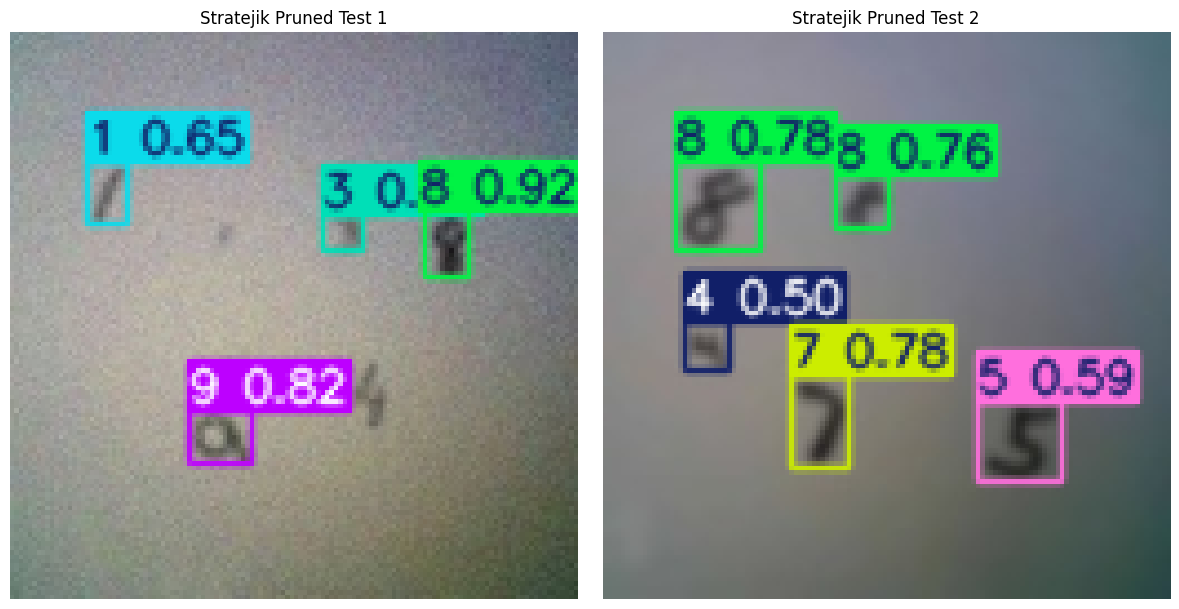

In [19]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
from glob import glob
import cv2

# --- MODEL VE TEST YOLLARI ---
PRUNED_MODEL_PATH = '/content/ESP32_YOLO_Project/models/2_PRUNED_MODEL.pt'
TEST_IMAGES_PATH = '/content/data/images/val'

# 1. Modeli yükle
if os.path.exists(PRUNED_MODEL_PATH):
    model_pruned = YOLO(PRUNED_MODEL_PATH)
    print("✅ Stratejik Budanmış Model yüklendi.")
else:
    print("❌ Hata: Model dosyası bulunamadı!")

# 2. Rastgele 2 resim seç
all_images = glob(os.path.join(TEST_IMAGES_PATH, "*.jpg"))
if len(all_images) >= 2:
    selected_images = random.sample(all_images, 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for i, img_path in enumerate(selected_images):
        # Tahmin (Inference)
        results = model_pruned.predict(source=img_path, imgsz=128, conf=0.25)

        # Küçük yazılar ve ince çizgilerle çizim
        res_plotted = results[0].plot(line_width=1, font_size=0.5, labels=True)

        # BGR -> RGB
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        axes[i].imshow(res_rgb)
        axes[i].set_title(f"Stratejik Pruned Test {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [20]:
import os
import shutil
from ultralytics import YOLO

print("🧠 ADIM 2: QAT Fine-tuning Başlıyor...")

# 1. Stratejik olarak budanmış modeli yükle
pruned_model_path = '/content/ESP32_YOLO_Project/models/2_PRUNED_MODEL.pt'
if not os.path.exists(pruned_model_path):
    print("❌ Hata: Budanmış model bulunamadı! Lütfen önceki adımı çalıştırın.")
else:
    model_qat = YOLO(pruned_model_path)

    # 2. İnce ayar eğitimi (Fine-tuning)
    # lr0=0.001: Mevcut ağırlıkları bozmamak için düşük öğrenme hızı
    model_qat.train(
        data='/content/data/custom_data.yaml',
        epochs=10,
        imgsz=128,
        batch=128,
        lr0=0.001,
        project='runs',
        name='qat_optimization',
        exist_ok=True,
        workers=12
    )

    # 3. En iyi ağırlıkları kalıcı olarak kaydet
    qat_best_path = 'runs/qat_optimization/weights/best.pt'
    qat_final_path = '/content/ESP32_YOLO_Project/models/3_QAT_MODEL.pt'

    if os.path.exists(qat_best_path):
        shutil.copy(qat_best_path, qat_final_path)
        print(f"✅ QAT aşaması tamamlandı ve model kaydedildi: {qat_final_path}")
    else:
        print("⚠️ Uyarı: Eğitim bitti ancak 'best.pt' bulunamadı.")

🧠 ADIM 2: QAT Fine-tuning Başlıyor...
New https://pypi.org/project/ultralytics/8.4.3 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/custom_data.yaml, degrees=0.0, deterministic=True, device=-1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/ESP32_YOLO_Project/models/2_PRUN

✅ QAT Modeli yüklendi. Test başlıyor...

image 1/1 /content/data/images/val/0016003.jpg: 128x128 1 4, 1 5, 1 8, 8.3ms
Speed: 0.4ms preprocess, 8.3ms inference, 1.4ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/data/images/val/0015205.jpg: 128x128 1 0, 1 1, 2 4s, 1 5, 1 6, 7.9ms
Speed: 0.4ms preprocess, 7.9ms inference, 1.5ms postprocess per image at shape (1, 3, 128, 128)


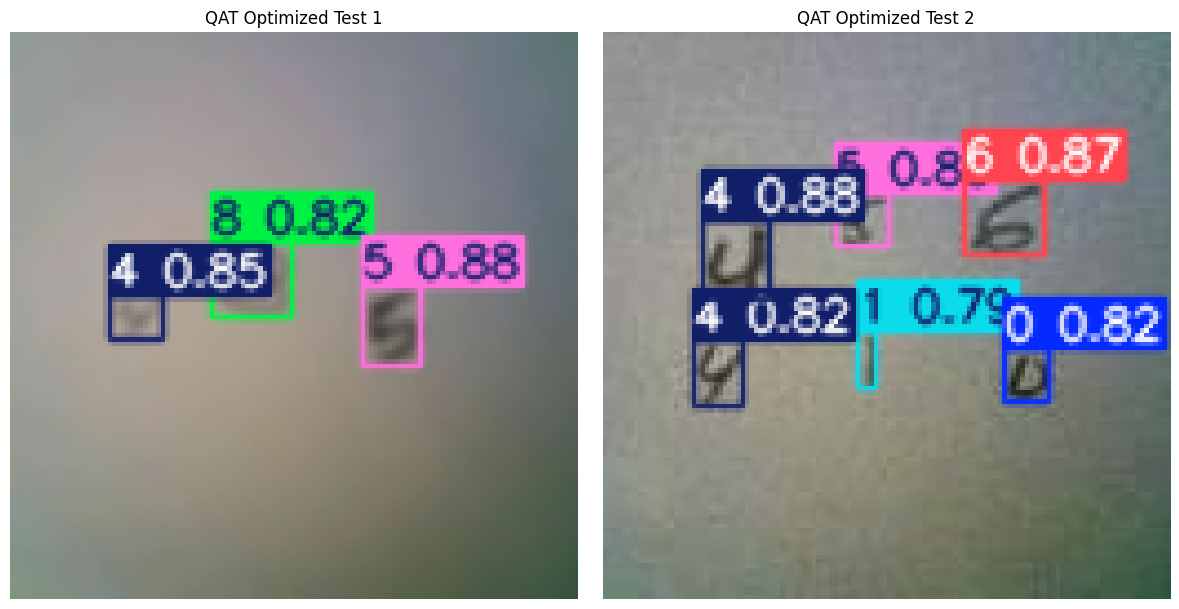

In [24]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
from glob import glob
import cv2

# --- MODEL VE TEST YOLLARI ---
QAT_MODEL_PATH = '/content/ESP32_YOLO_Project/models/3_QAT_MODEL.pt'
TEST_IMAGES_PATH = '/content/data/images/val'

# 1. QAT Modeli yükle
if os.path.exists(QAT_MODEL_PATH):
    model_qat = YOLO(QAT_MODEL_PATH)
    print("✅ QAT Modeli yüklendi. Test başlıyor...")
else:
    print("❌ Hata: QAT model dosyası bulunamadı!")

# 2. Rastgele 2 resim seç
all_images = glob(os.path.join(TEST_IMAGES_PATH, "*.jpg"))
if len(all_images) >= 2:
    selected_images = random.sample(all_images, 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for i, img_path in enumerate(selected_images):
        # Tahmin (Inference)
        results = model_qat.predict(source=img_path, imgsz=128, conf=0.25)

        # Küçük yazılar ve ince çizgilerle çizim
        res_plotted = results[0].plot(line_width=1, font_size=0.5, labels=True)

        # BGR -> RGB (Matplotlib için)
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        axes[i].imshow(res_rgb)
        axes[i].set_title(f"QAT Optimized Test {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [25]:
import os
from ultralytics import YOLO
import shutil

print("📦 ADIM 3: Full Integer Quantization (FIQ) ve TFLite Export Başlıyor...")

# 1. QAT ile eğitilmiş modeli yükle
qat_model_path = '/content/ESP32_YOLO_Project/models/3_QAT_MODEL.pt'
if not os.path.exists(qat_model_path):
    print("❌ Hata: QAT modeli bulunamadı! Lütfen Adım 3'ü çalıştırın.")
else:
    model_final = YOLO(qat_model_path)

    # 2. INT8 TFLite Export
    # int8=True: Tam sayılaştırmayı aktif eder
    # data: Temsilci veri seti (representative dataset) için gereklidir, kalibrasyon yapar
    model_final.export(
        format='tflite',
        int8=True,
        imgsz=128,
        data='/content/data/custom_data.yaml'
    )

    # 3. Nihai dosyayı doğru konuma taşıma
    # Ultralytics genellikle runs/qat_optimization/weights/best_int8.tflite altına kaydeder
    tflite_src = 'runs/qat_optimization/weights/best_int8.tflite'
    tflite_dest = '/content/ESP32_YOLO_Project/models/4_FULLY_INT8_MODEL.tflite'

    # Dosyayı bulmaya çalış ve kopyala
    if os.path.exists(tflite_src):
        shutil.copy(tflite_src, tflite_dest)
        print(f"🚀 BAŞARILI! Nihai modeliniz hazır: {tflite_dest}")
    else:
        print("⚠️ TFLite dosyası aranıyor...")
        !find runs/qat_optimization -name "*int8.tflite" -exec cp {} {tflite_dest} \;
        if os.path.exists(tflite_dest):
             print(f"🚀 BAŞARILI! Nihai model bulundu ve taşındı: {tflite_dest}")
        else:
             print("❌ Hata: TFLite dosyası oluşturulamadı.")

📦 ADIM 3: Full Integer Quantization (FIQ) ve TFLite Export Başlıyor...
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/ESP32_YOLO_Project/models/3_QAT_MODEL.pt' with input shape (1, 3, 128, 128) BCHW and output shape(s) (1, 14, 336) (5.9 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/data/custom_data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 308.3±97.3 MB/s, size: 6.2 KB)
Scanning /content/data/labels/val.cache... 2010 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2010/2010 936.7Mit/s 0.0s

ONNX: starting export with onnx 1.20.1 opset 22...
ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 1.0s, saved as '/content/ESP32_YOLO_Project/models/3_QAT_MODEL.onnx' (11.6 MB)
TensorFlow SavedModel: starting TFLite export 

In [26]:
import os

# Modelin yolu
tflite_path = '/content/ESP32_YOLO_Project/models/4_FULLY_INT8_MODEL.tflite'
header_path = '/content/ESP32_YOLO_Project/models/model_data.h'

def tflite_to_header(tflite_path, header_path):
    # TFLite dosyasını binary modda oku
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()

    # C++ array formatına çevir
    hex_lines = [f'0x{b:02x}' for b in tflite_content]

    # Header dosyasını oluştur
    with open(header_path, 'w') as f:
        f.write('#ifndef MODEL_DATA_H\n')
        f.write('#define MODEL_DATA_H\n\n')
        f.write(f'// Model size: {len(tflite_content)} bytes\n')
        f.write(f'const unsigned char model_data[] DATA_ALIGN_ATTRIBUTE = {{\n  ')

        # Her satıra 12 hex değeri gelecek şekilde düzenle
        for i, h in enumerate(hex_lines):
            f.write(h)
            if i < len(hex_lines) - 1:
                f.write(', ')
            if (i + 1) % 12 == 0:
                f.write('\n  ')

        f.write('\n};\n\n')
        f.write(f'const int model_data_len = {len(tflite_content)};\n\n')
        f.write('#endif // MODEL_DATA_H\n')

    print(f"✅ Başarılı! C++ Header dosyası oluşturuldu: {header_path}")
    print(f"📂 Dosya Boyutu: {len(tflite_content) / 1024:.2f} KB")

if os.path.exists(tflite_path):
    tflite_to_header(tflite_path, header_path)
else:
    print("❌ Hata: .tflite dosyası bulunamadı!")

✅ Başarılı! C++ Header dosyası oluşturuldu: /content/ESP32_YOLO_Project/models/model_data.h
📂 Dosya Boyutu: 3087.04 KB
